In [1]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import numpy as np
import scipy.linalg as la
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13,
                     'axes.titlesize': 14, 'figure.dpi': 100,
                     'lines.linewidth': 2, 'legend.fontsize': 11})
print("Cell 1 done.")

Cell 1 done.


In [2]:
# ============================================================
# Cell 2 — Spin operators
# ============================================================
def spin_operators(spin):
    """Sp, Sm, Sz, Id for given spin. States ordered m=+spin...-spin."""
    d  = int(2 * spin + 1)
    Sz = np.diag([spin - m for m in range(d)]).astype(complex)
    Sp = np.zeros((d, d), dtype=complex)
    Sm = np.zeros((d, d), dtype=complex)
    for k in range(d - 1):
        m          = spin - k
        val        = np.sqrt(spin*(spin+1) - m*(m-1))
        Sp[k,   k+1] = val
        Sm[k+1, k  ] = val
    return Sp, Sm, Sz, np.eye(d, dtype=complex)

# Verification
print("── Spin operator verification ──")
for s in [0.5, 1.0]:
    Sp, Sm, Sz, Id = spin_operators(s)
    print(f"  spin={s}: [S+,S-]-2Sz={np.max(np.abs(Sp@Sm-Sm@Sp-2*Sz)):.2e}  "
          f"[Sz,S+]-S+={np.max(np.abs(Sz@Sp-Sp@Sz-Sp)):.2e}")
print("Cell 2 done.")

── Spin operator verification ──
  spin=0.5: [S+,S-]-2Sz=0.00e+00  [Sz,S+]-S+=0.00e+00
  spin=1.0: [S+,S-]-2Sz=4.44e-16  [Sz,S+]-S+=0.00e+00
Cell 2 done.


In [3]:
# ============================================================
# Cell 3 — MPO builders
# ============================================================
def build_heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.0):
    """
    S=1/2 Heisenberg MPO, Dw=5.
    H = J/2*sum(S+S- + S-S+) + Jz*sum(Sz Sz) - h*sum(Sz)

    Bulk W[b_left, b_right, sigma_out, sigma_in]:
      [0,0]=I   [0,1]=S+  [0,2]=S-  [0,3]=Sz  [0,4]=-h*Sz
      [1,4]=J/2*S-  [2,4]=J/2*S+  [3,4]=Jz*Sz  [4,4]=I

    Left  boundary: row 0  -> shape (1, Dw, d, d)
    Right boundary: col 4  -> shape (Dw, 1, d, d)
    L_env[b=0]=1, R_env[b=0]=1
    """
    Sp, Sm, Sz, Id = spin_operators(0.5)
    d, Dw = 2, 5
    Wb = np.zeros((Dw, Dw, d, d), dtype=complex)
    Wb[0, 0] = Id;          Wb[0, 1] = Sp
    Wb[0, 2] = Sm;          Wb[0, 3] = Sz
    Wb[0, 4] = -h * Sz
    Wb[1, 4] = (J/2.0)*Sm;  Wb[2, 4] = (J/2.0)*Sp
    Wb[3, 4] = Jz * Sz;     Wb[4, 4] = Id
    mpo = []
    for i in range(L):
        if   i == 0:     mpo.append(Wb[0:1, :,    :, :].copy())
        elif i == L-1:   mpo.append(Wb[:,   4:5,  :, :].copy())
        else:            mpo.append(Wb.copy())
    return mpo


def build_aklt_mpo(L):
    """
    AKLT spin-1 MPO, Dw=14.
    H = sum [S.S + (1/3)(S.S)^2]

    Block structure: Dw = 1 + 3 + 9 + 1 = 14
      [0,0]=I
      [0,1:4]=Sa,  [0,4:13]=Sa*Sb
      [1:4,13]=Sa, [4:13,13]=(1/3)*Sa*Sb
      [13,13]=I

    Left  boundary: row 0  -> shape (1,  Dw, d, d)
    Right boundary: col 13 -> shape (Dw, 1,  d, d)
    L_env[b=0]=1, R_env[b=0]=1
    """
    Sp, Sm, Sz, Id = spin_operators(1.0)
    Sx = 0.5*(Sp+Sm);  Sy = -0.5j*(Sp-Sm)
    d, Dw = 3, 14
    Sops = [Sx, Sy, Sz]
    Qops = [Sops[a]@Sops[b] for a in range(3) for b in range(3)]
    Wb   = np.zeros((Dw, Dw, d, d), dtype=complex)
    Wb[0, 0] = Id
    for a  in range(3): Wb[0,    1+a ] = Sops[a]
    for ab in range(9): Wb[0,    4+ab] = Qops[ab]
    for a  in range(3): Wb[1+a,  13  ] = Sops[a]
    for ab in range(9): Wb[4+ab, 13  ] = (1.0/3.0)*Qops[ab]
    Wb[13, 13] = Id
    mpo = []
    for i in range(L):
        if   i == 0:   mpo.append(Wb[0:1,   :,    :, :].copy())
        elif i == L-1: mpo.append(Wb[:,      13:14,:, :].copy())
        else:          mpo.append(Wb.copy())
    return mpo


def mpo_exact_gs(mpo, d):
    """Full ED by contracting MPO (small L only)."""
    current = mpo[0][0].copy()
    for i in range(1, len(mpo)):
        Wi      = mpo[i]; P = current.shape[1]
        new     = np.einsum('bPQ,bBst->BPsQt', current, Wi, optimize=True)
        current = new.reshape(Wi.shape[1], P*d, P*d)
    H = current[0].real; H = 0.5*(H+H.T)
    vals, vecs = np.linalg.eigh(H)
    return float(vals[0]), vecs[:,0], H


# Verification
print("── Heisenberg MPO exact-diag ──")
ref_heis = {4:-1.616025403784, 6:-2.493577131515,
            8:-3.374932109083, 10:-4.258035207}
for L_t, E_ref in ref_heis.items():
    E0,_,_ = mpo_exact_gs(build_heisenberg_mpo(L_t), 2)
    print(f"  L={L_t:2d}: E={E0:.12f}  ref={E_ref}  err={abs(E0-E_ref):.2e}")

print("── AKLT MPO exact-diag ──")
for L_t in [4, 6, 8]:
    E0,_,_ = mpo_exact_gs(build_aklt_mpo(L_t), 3)
    E_ref  = -(L_t-1)*2.0/3.0
    print(f"  L={L_t:2d}: E={E0:.12f}  ref={E_ref:.12f}  err={abs(E0-E_ref):.2e}")
print("Cell 3 done.")

── Heisenberg MPO exact-diag ──
  L= 4: E=-1.616025403784  ref=-1.616025403784  err=4.39e-13
  L= 6: E=-2.493577133888  ref=-2.493577131515  err=2.37e-09
  L= 8: E=-3.374932598688  ref=-3.374932109083  err=4.90e-07
  L=10: E=-4.258035207283  ref=-4.258035207  err=2.83e-10
── AKLT MPO exact-diag ──
  L= 4: E=-2.000000000000  ref=-2.000000000000  err=4.44e-16
  L= 6: E=-3.333333333333  ref=-3.333333333333  err=4.00e-15
  L= 8: E=-4.666666666667  ref=-4.666666666667  err=5.33e-15
Cell 3 done.


In [4]:
# ============================================================
# Cell 4 — MPS init + canonicalisation
# ============================================================
def random_mps(L, d, D_max, seed=None):
    """Random MPS with natural bond dims min(D_max, d^i, d^(L-i))."""
    if seed is not None: np.random.seed(seed)
    tensors = []
    for i in range(L):
        Dl = max(1, min(D_max, d**i,       d**(L-i)))
        Dr = max(1, min(D_max, d**(i+1),   d**(L-i-1)))
        T  = (np.random.randn(Dl,d,Dr) + 1j*np.random.randn(Dl,d,Dr))
        tensors.append(T.astype(complex))
    return tensors


def left_canonicalize(tensors):
    """Left-canonicalise via QR. Returns new list; input unchanged."""
    L      = len(tensors)
    result = [t.copy() for t in tensors]
    C      = np.eye(result[0].shape[0], dtype=complex)
    for i in range(L-1):
        M              = np.tensordot(C, result[i], axes=([1],[0]))
        Dl, d_s, Dr    = M.shape
        M_mat          = M.reshape(Dl*d_s, Dr, order='C')
        Q, R           = np.linalg.qr(M_mat, mode='reduced')
        phases         = np.sign(np.diag(R))
        phases[phases==0] = 1.0
        Q              = Q * phases[np.newaxis,:]
        R              = phases[:,np.newaxis] * R
        result[i]      = Q.reshape(Dl, d_s, Q.shape[1], order='C')
        C              = R
    result[L-1] = np.tensordot(C, result[L-1], axes=([1],[0]))
    return result


def right_canonicalize(tensors):
    """Right-canonicalise via QR. Returns new list; input unchanged."""
    L      = len(tensors)
    result = [t.copy() for t in tensors]
    C      = np.eye(result[-1].shape[2], dtype=complex)
    for i in range(L-1, 0, -1):
        M              = np.tensordot(result[i], C, axes=([2],[0]))
        Dl, d_s, Dr    = M.shape
        M_mat          = M.reshape(Dl, d_s*Dr, order='C')
        Q, R           = np.linalg.qr(M_mat.T, mode='reduced')
        phases         = np.sign(np.diag(R))
        phases[phases==0] = 1.0
        Q              = Q * phases[np.newaxis,:]
        R              = phases[:,np.newaxis] * R
        result[i]      = Q.T.reshape(Q.shape[1], d_s, Dr, order='C')
        C              = R.T
    result[0] = np.tensordot(result[0], C, axes=([2],[0]))
    return result


def normalise_mps(tensors):
    """Normalise MPS in-place on copy."""
    result = [t.copy() for t in tensors]
    rho    = np.ones((1,1), dtype=complex)
    for T in result:
        rho = np.einsum('ab,asd,bse->de', rho, T.conj(), T, optimize=True)
    norm = float(np.sqrt(abs(rho[0,0].real)))
    if norm > 1e-15: result[0] = result[0] / norm
    return result


def mps_norm(tensors):
    rho = np.ones((1,1), dtype=complex)
    for T in tensors:
        rho = np.einsum('ab,asd,bse->de', rho, T.conj(), T, optimize=True)
    return float(rho[0,0].real)


def get_bond_dims(tensors):
    dims = [tensors[0].shape[0]]
    for T in tensors: dims.append(T.shape[2])
    return dims


def check_left_canonical(tensors):
    errs = []
    for T in tensors[:-1]:
        Dl,d_s,Dr = T.shape
        M = T.reshape(Dl*d_s, Dr, order='C')
        errs.append(float(np.max(np.abs(M.conj().T@M - np.eye(Dr)))))
    return errs


def check_right_canonical(tensors):
    errs = []
    for T in tensors[1:]:
        Dl,d_s,Dr = T.shape
        M = T.reshape(Dl, d_s*Dr, order='C')
        errs.append(float(np.max(np.abs(M@M.conj().T - np.eye(Dl)))))
    return errs


# Verification
print("── Canonicalisation verification ──")
mps0 = random_mps(10, 2, 16, seed=42)
lc   = left_canonicalize(mps0)
rc   = right_canonicalize(mps0)
print(f"  left-canonical  max err: {max(check_left_canonical(lc)):.2e}")
print(f"  right-canonical max err: {max(check_right_canonical(rc)):.2e}")
print("Cell 4 done.")

── Canonicalisation verification ──
  left-canonical  max err: 9.99e-16
  right-canonical max err: 8.88e-16
Cell 4 done.


In [5]:
# ============================================================
# Cell 5 — Environments
# ============================================================
# Convention:
#   L_env: (b, x, y)   MPO_bond x Bra_bond x Ket_bond
#   R_env: (B, X, Y)
#   MPO  : (b, B, s, t)
#   MPS  : (Dl, d, Dr)

def _L(rho, T):
    """Left transfer: rho(Dl,Dl), T(Dl,d,Dr) -> (Dr,Dr)."""
    return np.einsum('ab,asd,bse->de', rho, T.conj(), T, optimize=True)

def _R(rho, T):
    """Right transfer: rho(Dr,Dr), T(Dl,d,Dr) -> (Dl,Dl)."""
    return np.einsum('cd,asc,bsd->ab', rho, T.conj(), T, optimize=True)

def _L_op(rho, T, Op):
    """Left transfer with operator insertion."""
    return np.einsum('ab,ase,st,btf->ef', rho, T.conj(), Op, T, optimize=True)


def update_left_env(L_old, A, W):
    """
    L_old:(b,x,y)  A:(Dl,d,Dr)  W:(b,B,s,t)  ->  L_new:(B,X,Y)

    Step 1: T1[b,x,t,Y] = sum_y   L_old[b,x,y] * A[y,t,Y]
    Step 2: T2[x,Y,B,s] = sum_b,t T1[b,x,t,Y]  * W[b,B,s,t]
    Step 3: T3[Y,B,X]   = sum_x,s T2[x,Y,B,s]  * A*[x,s,X]
    """
    T1 = np.tensordot(L_old, A,       axes=([2],[0]))        # (b,x,t,Y)
    T2 = np.tensordot(T1,    W,       axes=([0,2],[0,3]))    # (x,Y,B,s)
    T3 = np.tensordot(T2,    A.conj(),axes=([0,3],[0,1]))    # (Y,B,X)
    return T3.transpose(1,2,0)                               # (B,X,Y)


def update_right_env(R_old, B, W):
    """
    R_old:(B,X,Y)  B:(Dl,d,Dr)  W:(b,B,s,t)  ->  R_new:(b,x,y)

    Step 1: T1[B,X,y,t] = sum_Y   R_old[B,X,Y] * B[y,t,Y]
    Step 2: T2[X,y,b,s] = sum_B,t T1[B,X,y,t]  * W[b,B,s,t]
    Step 3: T3[y,b,x]   = sum_X,s T2[X,y,b,s]  * B*[x,s,X]
    """
    T1 = np.tensordot(R_old, B,       axes=([2],[2]))        # (B,X,y,t)
    T2 = np.tensordot(T1,    W,       axes=([0,3],[1,3]))    # (X,y,b,s)
    T3 = np.tensordot(T2,    B.conj(),axes=([0,3],[2,1]))    # (y,b,x)
    return T3.transpose(1,2,0)                               # (b,x,y)


def init_environments(mpo, tensors):
    """
    Normalise + right-canonicalise MPS, then build all R_env
    sweeping right-to-left. Returns L_env, R_env, rc_tensors.

    Boundary conventions:
      L_env[0]   : shape (Dw_left=1,  1, 1),  [0,0,0]=1
      R_env[L-1] : shape (Dw_right=1, 1, 1),  [0,0,0]=1
    """
    L  = len(tensors)
    rc = right_canonicalize(normalise_mps(tensors))

    Dw_left  = mpo[0].shape[0]    # = 1 for boundary site
    Dw_right = mpo[-1].shape[1]   # = 1 for boundary site

    L_env = [None] * L
    R_env = [None] * L

    L_env[0]             = np.zeros((Dw_left,  1, 1), dtype=complex)
    L_env[0][0, 0, 0]    = 1.0
    R_env[L-1]           = np.zeros((Dw_right, 1, 1), dtype=complex)
    R_env[L-1][0, 0, 0]  = 1.0

    for i in range(L-1, 0, -1):
        R_env[i-1] = update_right_env(R_env[i], rc[i], mpo[i])

    return L_env, R_env, rc


# Verification
print("── Environment shape verification ──")
mpo_h = build_heisenberg_mpo(6)
mps_h = random_mps(6, d=2, D_max=4, seed=0)
L_env, R_env, rc = init_environments(mpo_h, mps_h)
print(f"  L_env[0] shape : {L_env[0].shape}  (expect (1,1,1))")
print(f"  R_env[5] shape : {R_env[5].shape}  (expect (1,1,1))")
print(f"  R_env[0] shape : {R_env[0].shape}")
print("Cell 5 done.")

── Environment shape verification ──
  L_env[0] shape : (1, 1, 1)  (expect (1,1,1))
  R_env[5] shape : (1, 1, 1)  (expect (1,1,1))
  R_env[0] shape : (5, 2, 2)
Cell 5 done.


In [6]:
# ============================================================
# Cell 6 — Matrix-free H_eff + local solver + SVD truncation
# ============================================================

def apply_Heff(v, L_env, R_env, W, shape):
    """
    Matrix-free action of H_eff on vector v.

    L_env:(b,x,y)  R_env:(B,X,Y)  W:(b,B,s,t)  shape:(Dl,d,Dr)

    Step 1: T1[b,x,t,Y] = sum_y   L[b,x,y]  * V[y,t,Y]
    Step 2: T2[B,x,s,Y] = sum_b,t T1[b,x,t,Y] * W[b,B,s,t]
    Step 3: out[x,s,X]  = sum_B,Y T2[B,x,s,Y] * R[B,X,Y]
    """
    V  = v.reshape(shape)
    T1 = np.tensordot(L_env, V,     axes=([2],[0]))          # (b,x,t,Y)
    T2 = np.tensordot(T1,    W,     axes=([0,2],[0,3]))      # (x,Y,B,s)
    T2 = T2.transpose(2,0,3,1)                               # (B,x,s,Y)
    Vo = np.tensordot(T2,    R_env, axes=([0,3],[0,2]))      # (x,s,X)
    return Vo.ravel()


def solve_local(L_env, R_env, W, M_init):
    """
    Lowest eigenpair of H_eff via Lanczos (dense fallback for small dim).
    Returns (energy, optimised tensor of shape M_init.shape).
    """
    shape = M_init.shape
    dim   = int(np.prod(shape))
    v0    = M_init.ravel().astype(complex)

    def matvec(v):
        return apply_Heff(v, L_env, R_env, W, shape)

    def dense_solve():
        H = np.zeros((dim,dim), dtype=complex)
        for j in range(dim):
            ej = np.zeros(dim, dtype=complex); ej[j] = 1.0
            H[:,j] = matvec(ej)
        H = 0.5*(H + H.conj().T)
        try:
            ev, evec = np.linalg.eigh(H)
            return float(ev[0].real), evec[:,0].reshape(shape)
        except np.linalg.LinAlgError:
            ev, evec = np.linalg.eig(H)
            idx = np.argsort(ev.real)
            return float(ev[idx[0]].real), evec[:,idx[0]].reshape(shape)

    if dim <= 64:
        return dense_solve()

    ncv  = min(dim, max(20, dim//4))
    H_op = LinearOperator((dim,dim), matvec=matvec, dtype=complex)
    try:
        ev, evec = eigsh(H_op, k=1, which='SA',
                         v0=v0, tol=1e-10, ncv=ncv, maxiter=1000)
        return float(ev[0].real), evec[:,0].reshape(shape)
    except Exception:
        return dense_solve()


def svd_truncate(M, D_max, eps=1e-12):
    """
    SVD with truncation. Returns U, s, Vh, truncation_error.
    Singular values guaranteed descending.
    """
    try:
        U, s, Vh = la.svd(M, full_matrices=False)
    except la.LinAlgError:
        U, s, Vh = la.svd(M, full_matrices=False,
                           lapack_driver='gesvd')
    idx  = np.argsort(s)[::-1]
    s, U, Vh = s[idx], U[:,idx], Vh[idx,:]
    s_max    = s[0] if s[0] > 1e-300 else 1e-300
    thresh   = max(eps*s_max, 1e-14)
    D_keep   = max(1, min(D_max, int(np.sum(s > thresh))))
    trunc    = float(np.sum(s[D_keep:]**2))
    return U[:,:D_keep], s[:D_keep], Vh[:D_keep,:], trunc


# Verification: apply_Heff vs dense H_eff
print("── apply_Heff correctness check ──")
mpo_t = build_heisenberg_mpo(4)
mps_t = random_mps(4, d=2, D_max=2, seed=7)
Lt, Rt, rct = init_environments(mpo_t, mps_t)
Lt[1] = update_left_env(Lt[0], rct[0], mpo_t[0])
Lt[2] = update_left_env(Lt[1], rct[1], mpo_t[1])
shape_t = rct[2].shape
dim_t   = int(np.prod(shape_t))
H_dense = np.zeros((dim_t,dim_t), dtype=complex)
for j in range(dim_t):
    ej = np.zeros(dim_t, dtype=complex); ej[j]=1.0
    H_dense[:,j] = apply_Heff(ej, Lt[2], Rt[2], mpo_t[2], shape_t)
herm_err = np.max(np.abs(H_dense - H_dense.conj().T))
v_test   = np.random.randn(dim_t).astype(complex)
mv_err   = np.max(np.abs(apply_Heff(v_test,Lt[2],Rt[2],mpo_t[2],shape_t)
                         - H_dense@v_test))
print(f"  H_eff Hermiticity error : {herm_err:.2e}  (expect < 1e-13)")
print(f"  matvec vs dense err     : {mv_err:.2e}  (expect < 1e-13)")
print("Cell 6 done.")

── apply_Heff correctness check ──
  H_eff Hermiticity error : 5.59e-17  (expect < 1e-13)
  matvec vs dense err     : 5.55e-17  (expect < 1e-13)
Cell 6 done.


In [7]:
# ============================================================
# Cell 7 — Single-site DMRG engine
# ============================================================

def dmrg_single_site(mpo, d, D_max, n_sweeps=20, eps_svd=1e-12,
                     conv_tol=1e-8, seed=42, verbose=True):
    """
    Single-site DMRG with MPO/MPS environment-based
    matrix-free local Hamiltonian action.

    Uses natural bond-dimension initialisation (random_mps),
    which correctly survives right_canonicalize inside
    init_environments without bond compression.
    """
    L       = len(mpo)
    tensors = random_mps(L, d, D_max, seed=seed)
    L_env, R_env, tensors = init_environments(mpo, tensors)
    energies=[]; trunc_errs=[]; E_prev=np.inf

    for sweep in range(n_sweeps):

        # ── Right sweep ───────────────────────────────────────
        sw_trunc = []
        for i in range(L-1):
            E, M_opt   = solve_local(L_env[i], R_env[i], mpo[i], tensors[i])
            Dl,d_s,Dr  = M_opt.shape
            U,s,Vh,eta = svd_truncate(
                M_opt.reshape(Dl*d_s, Dr, order='C'), D_max, eps_svd)
            Dn = len(s)
            sw_trunc.append(eta)
            tensors[i]   = U.reshape(Dl, d_s, Dn, order='C')
            tensors[i+1] = np.tensordot(np.diag(s)@Vh,
                                         tensors[i+1], axes=([1],[0]))
            L_env[i+1]   = update_left_env(L_env[i], tensors[i], mpo[i])

        energies.append(float(E))
        trunc_errs.append(max(sw_trunc) if sw_trunc else 0.0)
        dE = abs(E - E_prev) / L
        if verbose:
            print(f"  sweep{sweep+1:3d}R | E={E:.10f} | "
                  f"dE/site={dE:.2e} | trunc={trunc_errs[-1]:.2e}")

        # ── Left sweep ────────────────────────────────────────
        sw_trunc = []
        for i in range(L-1, 0, -1):
            E, M_opt   = solve_local(L_env[i], R_env[i], mpo[i], tensors[i])
            Dl,d_s,Dr  = M_opt.shape
            U,s,Vh,eta = svd_truncate(
                M_opt.reshape(Dl, d_s*Dr, order='C'), D_max, eps_svd)
            Dn = len(s)
            sw_trunc.append(eta)
            tensors[i]   = Vh.reshape(Dn, d_s, Dr, order='C')
            tensors[i-1] = np.tensordot(tensors[i-1], U@np.diag(s),
                                         axes=([2],[0]))
            R_env[i-1]   = update_right_env(R_env[i], tensors[i], mpo[i])

        energies.append(float(E))
        trunc_errs.append(max(sw_trunc) if sw_trunc else 0.0)
        dE = abs(E - E_prev) / L
        if verbose:
            print(f"  sweep{sweep+1:3d}L | E={E:.10f} | "
                  f"dE/site={dE:.2e} | trunc={trunc_errs[-1]:.2e}")

        if dE < conv_tol and sweep >= 1:
            if verbose: print(f"  Converged after {sweep+1} sweeps.")
            break
        E_prev = float(E)

    return energies, trunc_errs, tensors


# ── Verification ──────────────────────────────────────────────
print("── L=2 Heisenberg (expect E=-0.75) ──")
E2,_,_ = dmrg_single_site(build_heisenberg_mpo(2), d=2, D_max=4,
                            n_sweeps=10, conv_tol=1e-12,
                            seed=0, verbose=False)
print(f"  E={E2[-1]:.14f}  err={abs(E2[-1]-(-0.75)):.2e}")

print("\n── Heisenberg L=4,6,8 vs exact diag ──")
ref_vals = {4:-1.616025403784, 6:-2.493577131515, 8:-3.374932109083}
for L_t, E_ref in ref_vals.items():
    Es,ts,_ = dmrg_single_site(build_heisenberg_mpo(L_t), d=2,
                                D_max=16, n_sweeps=30, conv_tol=1e-10,
                                seed=0, verbose=False)
    print(f"  L={L_t}: E={Es[-1]:.12f}  ref={E_ref:.12f}  "
          f"err={abs(Es[-1]-E_ref):.2e}  trunc={ts[-1]:.2e}")

print("\n── AKLT L=4,6,8,10 (exact: E=-(L-1)*2/3) ──")
for L_t in [4, 6, 8, 10]:
    E_ref = -(L_t-1)*2.0/3.0
    Es,ts,_ = dmrg_single_site(build_aklt_mpo(L_t), d=3,
                                D_max=4, n_sweeps=20, conv_tol=1e-10,
                                seed=0, verbose=False)
    print(f"  L={L_t:2d}: E={Es[-1]:.12f}  ref={E_ref:.12f}  "
          f"err={abs(Es[-1]-E_ref):.2e}  trunc={ts[-1]:.2e}")
print("Cell 7 done.")

── L=2 Heisenberg (expect E=-0.75) ──
  E=-0.75000000000000  err=0.00e+00

── Heisenberg L=4,6,8 vs exact diag ──
  L=4: E=-1.616025403784  ref=-1.616025403784  err=4.39e-13  trunc=0.00e+00
  L=6: E=-2.493577133888  ref=-2.493577131515  err=2.37e-09  trunc=0.00e+00
  L=8: E=-3.374932598688  ref=-3.374932109083  err=4.90e-07  trunc=0.00e+00

── AKLT L=4,6,8,10 (exact: E=-(L-1)*2/3) ──
  L= 4: E=-2.000000000000  ref=-2.000000000000  err=8.88e-16  trunc=0.00e+00
  L= 6: E=-3.333333333333  ref=-3.333333333333  err=1.33e-14  trunc=0.00e+00
  L= 8: E=-4.666666666667  ref=-4.666666666667  err=1.78e-15  trunc=0.00e+00
  L=10: E=-6.000000000000  ref=-6.000000000000  err=1.42e-14  trunc=0.00e+00
Cell 7 done.


In [8]:
# ============================================================
# Cell 8 (revised) — Observables with auto-switching entropy
# ============================================================

def entanglement_entropy_fullstate(tensors):
    """
    Exact entropy via full state vector bipartition SVD.
    Only for small L: L<=20 (d=2) or L<=12 (d=3).
    """
    L      = len(tensors)
    d_site = tensors[0].shape[1]

    psi = tensors[0].reshape(d_site, tensors[0].shape[2])
    for i in range(1, L):
        T         = tensors[i]
        Dl,d_s,Dr = T.shape
        psi       = psi @ T.reshape(Dl, d_s*Dr)
        psi       = psi.reshape(-1, Dr)
    psi = psi.ravel()
    psi /= np.linalg.norm(psi)

    S_ent = []
    for bond in range(L-1):
        dim_l = d_site**(bond+1)
        dim_r = d_site**(L-bond-1)
        try:
            _, s, _ = np.linalg.svd(psi.reshape(dim_l, dim_r),
                                     full_matrices=False)
        except Exception:
            _, s, _ = la.svd(psi.reshape(dim_l, dim_r),
                              full_matrices=False, lapack_driver='gesvd')
        s2 = s**2; s2 = s2[s2>1e-15]; s2 /= s2.sum()
        S_ent.append(float(-np.sum(s2*np.log(s2))))
    return np.array(S_ent)


def entanglement_entropy_mixedcanon(tensors):
    """
    Entropy via mixed-canonical form at each bond.
    Works for any system size. Cost O(L * D^3).

    For each bond i:
      Left-canonicalise sites 0..i via QR sweep,
      accumulating gauge matrix C. SVD(C) gives Schmidt values.
    """
    L     = len(tensors)
    tn    = normalise_mps(tensors)
    S_ent = []

    for bond in range(L-1):
        result = [t.copy() for t in tn]
        C      = np.ones((1,1), dtype=complex)
        for i in range(bond+1):
            M          = np.tensordot(C, result[i], axes=([1],[0]))
            Dl,d_s,Dr  = M.shape
            M_mat      = M.reshape(Dl*d_s, Dr, order='C')
            Q, R       = np.linalg.qr(M_mat, mode='reduced')
            result[i]  = Q.reshape(Dl, d_s, Q.shape[1], order='C')
            C          = R
        try:
            _, s, _ = la.svd(C, full_matrices=False)
        except la.LinAlgError:
            _, s, _ = la.svd(C, full_matrices=False,
                              lapack_driver='gesvd')
        s2 = s**2; s2 = s2[s2>1e-15]; s2 /= s2.sum()
        S_ent.append(float(-np.sum(s2*np.log(s2))))
    return np.array(S_ent)


def entanglement_entropy(tensors):
    """
    Auto-switching entropy:
      - Full state SVD for small systems (d^L <= 10^6)
      - Mixed-canonical QR for larger systems
    """
    L      = len(tensors)
    d_site = tensors[0].shape[1]
    if d_site**L <= 1_000_000:
        return entanglement_entropy_fullstate(tensors)
    else:
        return entanglement_entropy_mixedcanon(tensors)


def sz_sz_correlation(tensors, i0):
    """
    C(r) = <Sz_{i0} Sz_{i0+r}> for r=0,1,...,L-1-i0.
    Transfer matrix method on left-canonical MPS.
    """
    d_site = tensors[0].shape[1]
    spin   = (d_site-1)/2.0
    _, _, Sz, _ = spin_operators(spin)

    L  = len(tensors)
    lc = left_canonicalize(normalise_mps(tensors))

    rho_n = np.ones((1,1), dtype=complex)
    for T in lc:
        rho_n = _L(rho_n, T)
    norm_val = float(rho_n[0,0].real)

    rho_right      = [None]*L
    rho_right[L-1] = np.ones((1,1), dtype=complex)
    for i in range(L-2, -1, -1):
        rho_right[i] = _R(rho_right[i+1], lc[i+1])

    rho_left = np.ones((1,1), dtype=complex)
    for i in range(i0):
        rho_left = _L(rho_left, lc[i])

    T_i0 = lc[i0]
    mid0 = _L_op(rho_left, T_i0, Sz@Sz)
    corr = [float(np.einsum('ab,ab->', mid0,
                             rho_right[i0], optimize=True).real) / norm_val]

    rho_Sz = _L_op(rho_left, T_i0, Sz)
    for j in range(i0+1, L):
        T_j  = lc[j]
        midj = _L_op(rho_Sz, T_j, Sz)
        corr.append(float(np.einsum('ab,ab->', midj,
                                     rho_right[j], optimize=True).real
                          ) / norm_val)
        rho_Sz = _L(rho_Sz, T_j)

    return np.array(corr)


def string_order_parameter(tensors):
    """
    O(i,j) = <Sz_i [prod_{k=i+1}^{j-1} exp(i*pi*Sz_k)] Sz_j>
    For AKLT spin-1: converges to -4/9 for |i-j|>=2.
    """
    d_site = tensors[0].shape[1]
    spin   = (d_site-1)/2.0
    _, _, Sz, _ = spin_operators(spin)
    exp_Sz = la.expm(1j*np.pi*Sz)

    L  = len(tensors)
    lc = left_canonicalize(normalise_mps(tensors))

    rho_n = np.ones((1,1), dtype=complex)
    for T in lc: rho_n = _L(rho_n, T)
    norm_val = float(rho_n[0,0].real)

    rho_right      = [None]*L
    rho_right[L-1] = np.ones((1,1), dtype=complex)
    for i in range(L-2, -1, -1):
        rho_right[i] = _R(rho_right[i+1], lc[i+1])

    rho_left_list      = [None]*L
    rho_left_list[0]   = np.ones((1,1), dtype=complex)
    for i in range(1, L):
        rho_left_list[i] = _L(rho_left_list[i-1], lc[i-1])

    O_mat = np.zeros((L, L))

    for i in range(L):
        T_i      = lc[i]
        rho_left = rho_left_list[i]

        mid_ii     = _L_op(rho_left, T_i, Sz@Sz)
        O_mat[i,i] = float(np.einsum('ab,ab->', mid_ii,
                                      rho_right[i], optimize=True).real
                           ) / norm_val

        rho_prop = _L_op(rho_left, T_i, Sz)

        for j in range(i+1, L):
            T_j    = lc[j]
            mid_j  = _L_op(rho_prop, T_j, Sz)
            val    = float(np.einsum('ab,ab->', mid_j,
                                      rho_right[j], optimize=True).real
                           ) / norm_val
            O_mat[i,j] = val
            O_mat[j,i] = val
            rho_prop   = _L_op(rho_prop, T_j, exp_Sz)

    return O_mat


# ── Verification ──────────────────────────────────────────────
print("── Entropy method check ──")
print("  d=2, L=8  : uses fullstate  "
      f"(3^8={2**8}, <= 1e6: {2**8 <= 1_000_000})")
print("  d=3, L=20 : uses mixedcanon "
      f"(3^20={3**20:.2e}, <= 1e6: {3**20 <= 1_000_000})")
print("  d=3, L=12 : uses fullstate  "
      f"(3^12={3**12}, <= 1e6: {3**12 <= 1_000_000})")

print("\n── Heisenberg L=8 entropy vs ED ──")
_,_, mps_h8 = dmrg_single_site(build_heisenberg_mpo(8), d=2,
                                 D_max=16, n_sweeps=20, conv_tol=1e-10,
                                 seed=0, verbose=False)
E_ed, psi_ed, _ = mpo_exact_gs(build_heisenberg_mpo(8), d=2)
psi_ed = psi_ed / np.linalg.norm(psi_ed)
S_ed   = []
for bond in range(7):
    _, s_ed, _ = np.linalg.svd(
        psi_ed.reshape(2**(bond+1), 2**(7-bond)), full_matrices=False)
    s2 = s_ed**2; s2=s2[s2>1e-15]; s2/=s2.sum()
    S_ed.append(float(-np.sum(s2*np.log(s2))))
S_ed = np.array(S_ed)
S_h8 = entanglement_entropy(mps_h8)
C_h8 = sz_sz_correlation(mps_h8, i0=0)
print(f"  Entropy DMRG : {np.round(S_h8, 6)}")
print(f"  Entropy ED   : {np.round(S_ed, 6)}")
print(f"  Max err      : {np.max(np.abs(S_h8-S_ed)):.2e}  (expect <1e-10)")
print(f"  C(0)={C_h8[0]:.6f} (expect 0.25)  C(1)={C_h8[1]:.6f} (expect <0)")

print("\n── AKLT L=12 entropy (fullstate, exact) ──")
_,_, mps_a12 = dmrg_single_site(build_aklt_mpo(12), d=3,
                                  D_max=2, n_sweeps=20, conv_tol=1e-10,
                                  seed=0, verbose=False)
S_a12 = entanglement_entropy(mps_a12)   # uses fullstate (3^12=531441)
print(f"  Entropy : {np.round(S_a12, 6)}")
print(f"  Bulk mean={np.mean(S_a12[2:-2]):.6f}  "
      f"ln2={np.log(2):.6f}  err={abs(np.mean(S_a12[2:-2])-np.log(2)):.2e}")

print("\n── AKLT L=16 entropy (mixedcanon) ──")
_,_, mps_a16 = dmrg_single_site(build_aklt_mpo(16), d=3,
                                  D_max=2, n_sweeps=20, conv_tol=1e-10,
                                  seed=0, verbose=False)
S_a16 = entanglement_entropy(mps_a16)   # uses mixedcanon (3^16=43M)
print(f"  Entropy : {np.round(S_a16, 6)}")
print(f"  Bulk mean={np.mean(S_a16[2:-2]):.6f}  "
      f"ln2={np.log(2):.6f}  err={abs(np.mean(S_a16[2:-2])-np.log(2)):.2e}")
print(f"  Symm err={np.max(np.abs(S_a16-S_a16[::-1])):.2e}")

print("\n── AKLT L=16 D=2 full observables ──")
C_a16 = sz_sz_correlation(mps_a16, i0=4)
O_a16 = string_order_parameter(mps_a16)
i_ref_test = 6
str_vals = [O_a16[i_ref_test, j] for j in range(i_ref_test+2, 16)]
print(f"  C(0)={C_a16[0]:.8f}  expect={2./3.:.8f}")
print(f"  C(1)={C_a16[1]:.8f}  expect={-4./9.:.8f}")
print(f"  String order mean={np.mean(str_vals):.8f}  "
      f"exact={-4./9.:.8f}  err={abs(np.mean(str_vals)-(-4./9.)):.2e}")
print("Cell 8 done.")

── Entropy method check ──
  d=2, L=8  : uses fullstate  (3^8=256, <= 1e6: True)
  d=3, L=20 : uses mixedcanon (3^20=3.49e+09, <= 1e6: False)
  d=3, L=12 : uses fullstate  (3^12=531441, <= 1e6: True)

── Heisenberg L=8 entropy vs ED ──
  Entropy DMRG : [0.693147 0.397179 0.720945 0.456976 0.720945 0.397179 0.693147]
  Entropy ED   : [0.693147 0.397179 0.720945 0.456976 0.720945 0.397179 0.693147]
  Max err      : 1.11e-15  (expect <1e-10)
  C(0)=0.250000 (expect 0.25)  C(1)=-0.220413 (expect <0)

── AKLT L=12 entropy (fullstate, exact) ──
  Entropy : [0.636516 0.686963 0.692463 0.693073 0.69314  0.693147 0.69314  0.693073
 0.692463 0.686963 0.636516]
  Bulk mean=0.692929  ln2=0.693147  err=2.19e-04

── AKLT L=16 entropy (mixedcanon) ──
  Entropy : [0.636514 0.686962 0.692461 0.693071 0.693139 0.693146 0.693147 0.693147
 0.693147 0.693146 0.693139 0.693071 0.692461 0.686962 0.636514]
  Bulk mean=0.693007  ln2=0.693147  err=1.40e-04
  Symm err=1.02e-12

── AKLT L=16 D=2 full observables 

In [9]:
# ============================================================
# Cell 9 (revised) — Physics runs with reduced system sizes
# ============================================================

# ── Run 1: Heisenberg E vs D (L=12) ──────────────────────────
print("=" * 60)
print("RUN 1: Heisenberg E vs D  (L=12)")
print("=" * 60)
L_heis = 12
D_list = [4, 8, 12, 16, 24, 32]
E_vs_D = []
for D in D_list:
    Es,ts,_ = dmrg_single_site(build_heisenberg_mpo(L_heis), d=2,
                                D_max=D, n_sweeps=30, conv_tol=1e-9,
                                seed=1, verbose=False)
    E_vs_D.append(Es[-1])
    print(f"  D={D:3d}: E={Es[-1]:.10f}  trunc={ts[-1]:.2e}")

# ── Run 2: Heisenberg E vs L (D=16) ──────────────────────────
print("\n" + "=" * 60)
print("RUN 2: Heisenberg E vs L  (D=16)")
print("=" * 60)
L_list = [4, 6, 8, 10, 12]
E_vs_L = []
for L_h in L_list:
    Es,ts,_ = dmrg_single_site(build_heisenberg_mpo(L_h), d=2,
                                D_max=16, n_sweeps=20, conv_tol=1e-8,
                                seed=1, verbose=False)
    E_vs_L.append(Es[-1])
    print(f"  L={L_h:3d}: E={Es[-1]:.10f}  E/L={Es[-1]/L_h:.8f}")

# ── Run 3: Heisenberg L=12 D=32 ground state ─────────────────
print("\n" + "=" * 60)
print("RUN 3: Heisenberg L=12 D=32 (entropy + correlations)")
print("=" * 60)
Es_h,ts_h,mps_h = dmrg_single_site(
    build_heisenberg_mpo(L_heis), d=2, D_max=32,
    n_sweeps=20, conv_tol=1e-9, seed=1, verbose=True)
# L=12, d=2: 2^12=4096 <= 1e6, uses fullstate (exact)
S_h = entanglement_entropy(mps_h)
C_h = sz_sz_correlation(mps_h, i0=3)
print(f"\n  max S = {np.max(S_h):.6f}")
print(f"  symm  = {np.max(np.abs(S_h-S_h[::-1])):.2e}")
print(f"  S     = {np.round(S_h,6)}")

# ── Run 4: AKLT E vs L (D=4) ─────────────────────────────────
print("\n" + "=" * 60)
print("RUN 4: AKLT E vs L  (D=4)")
print("=" * 60)
L_aklt_list = [4, 6, 8, 10, 12]
E_aklt      = []
E_aklt_ref  = []
for L_a in L_aklt_list:
    E_ref = -(L_a-1)*2.0/3.0
    Es,ts,_ = dmrg_single_site(build_aklt_mpo(L_a), d=3,
                                D_max=4, n_sweeps=20, conv_tol=1e-9,
                                seed=1, verbose=False)
    E_aklt.append(Es[-1])
    E_aklt_ref.append(E_ref)
    print(f"  L={L_a:3d}: E={Es[-1]:.10f}  ref={E_ref:.10f}  "
          f"err={abs(Es[-1]-E_ref):.2e}  trunc={ts[-1]:.2e}")

# ── Run 5: AKLT L=12 D=2 (exact, uses fullstate entropy) ─────
print("\n" + "=" * 60)
print("RUN 5: AKLT L=12 D=2 (exact MPS)")
print("=" * 60)
L_ac = 12
Es_ac,ts_ac,mps_ac = dmrg_single_site(
    build_aklt_mpo(L_ac), d=3, D_max=2,
    n_sweeps=20, conv_tol=1e-10, seed=1, verbose=True)
E_ref_ac = -(L_ac-1)*2.0/3.0
print(f"\n  Final E = {Es_ac[-1]:.14f}")
print(f"  Exact E = {E_ref_ac:.14f}")
print(f"  Error   = {abs(Es_ac[-1]-E_ref_ac):.2e}")

# 3^12 = 531441 <= 1e6: uses fullstate (exact)
S_a = entanglement_entropy(mps_ac)
C_a = sz_sz_correlation(mps_ac, i0=3)
O_a = string_order_parameter(mps_ac)

print(f"\n  Bulk entropy : {np.mean(S_a[2:-2]):.8f}"
      f"  ln2={np.log(2):.8f}"
      f"  err={abs(np.mean(S_a[2:-2])-np.log(2)):.2e}")

i_ref    = L_ac//2
str_vals = [O_a[i_ref, j] for j in range(i_ref+2, L_ac)]
print(f"  String order : {np.mean(str_vals):.8f}"
      f"  exact={-4./9.:.8f}"
      f"  err={abs(np.mean(str_vals)-(-4./9.)):.2e}")

print("Cell 9 done.")

RUN 1: Heisenberg E vs D  (L=12)
  D=  4: E=-5.1323668267  trunc=0.00e+00
  D=  8: E=-5.1420470549  trunc=0.00e+00
  D= 12: E=-5.1420822116  trunc=0.00e+00
  D= 16: E=-5.1420905740  trunc=0.00e+00
  D= 24: E=-5.1420906320  trunc=0.00e+00
  D= 32: E=-5.1420906328  trunc=0.00e+00

RUN 2: Heisenberg E vs L  (D=16)
  L=  4: E=-1.6160254038  E/L=-0.40400635
  L=  6: E=-2.4935771339  E/L=-0.41559619
  L=  8: E=-3.3749325987  E/L=-0.42186657
  L= 10: E=-4.2580352046  E/L=-0.42580352
  L= 12: E=-5.1420905740  E/L=-0.42850755

RUN 3: Heisenberg L=12 D=32 (entropy + correlations)
  sweep  1R | E=-5.1420904286 | dE/site=inf | trunc=0.00e+00
  sweep  1L | E=-5.1420906328 | dE/site=inf | trunc=0.00e+00
  sweep  2R | E=-5.1420906328 | dE/site=4.93e-14 | trunc=0.00e+00
  sweep  2L | E=-5.1420906328 | dE/site=5.99e-14 | trunc=0.00e+00
  Converged after 2 sweeps.

  max S = 0.748112
  symm  = 2.82e-12
  S     = [0.693147 0.414031 0.729338 0.511429 0.748112 0.536833 0.748112 0.511429
 0.729338 0.414031 

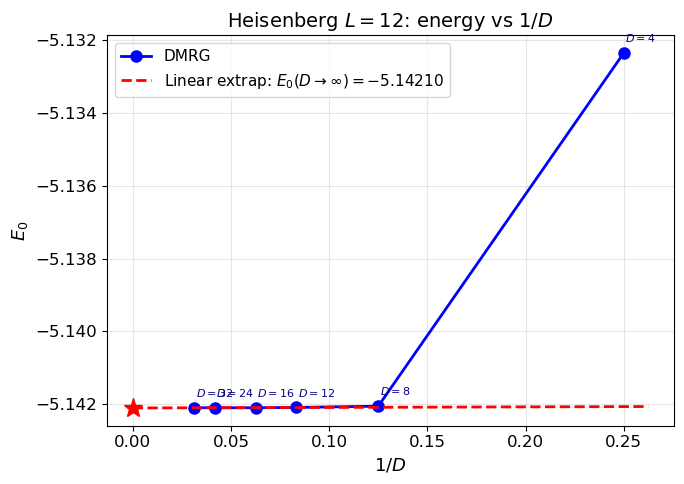

Saved fig1


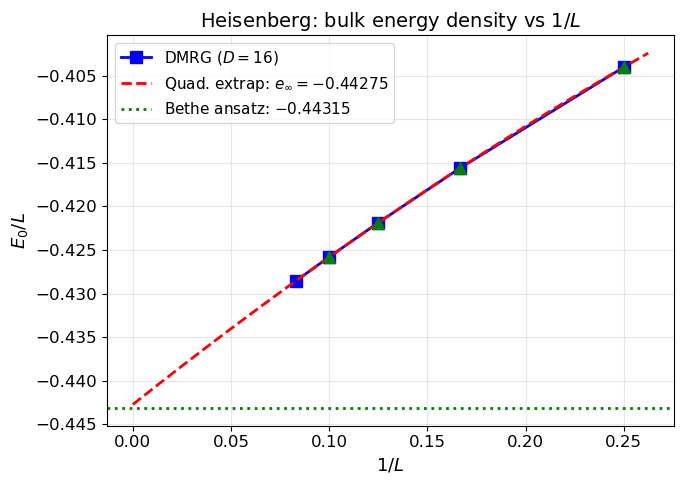

Saved fig2


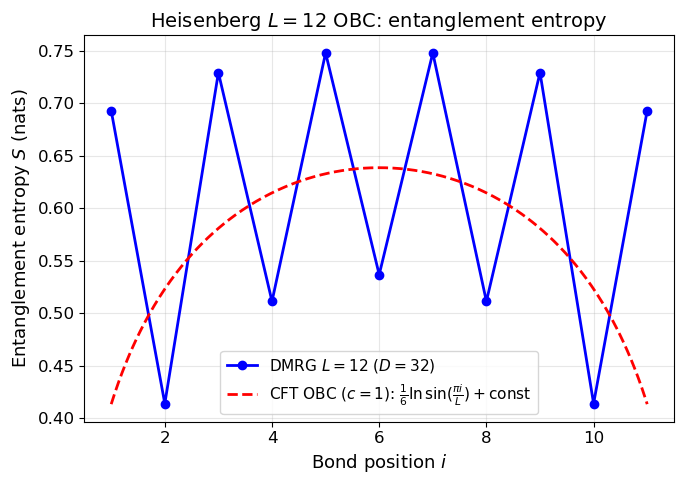

Saved fig3


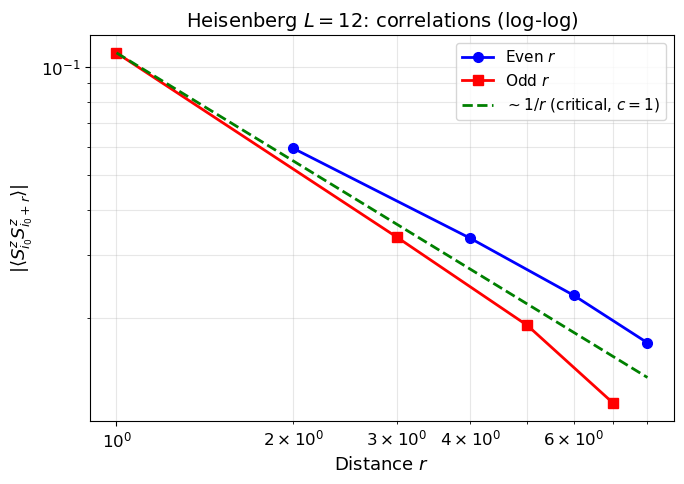

Saved fig4


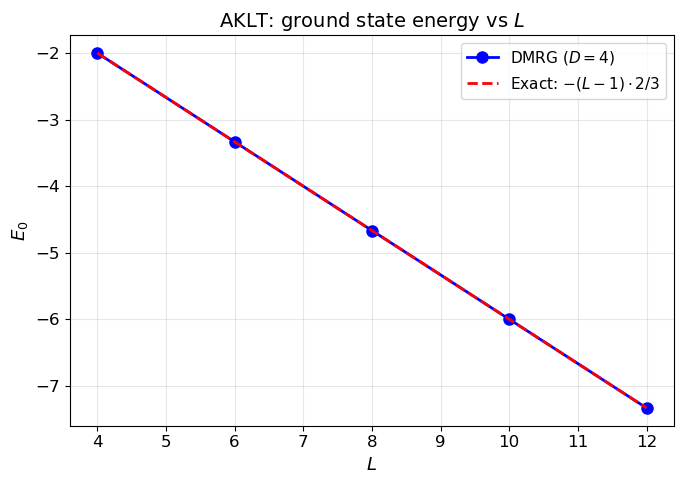

Saved fig5


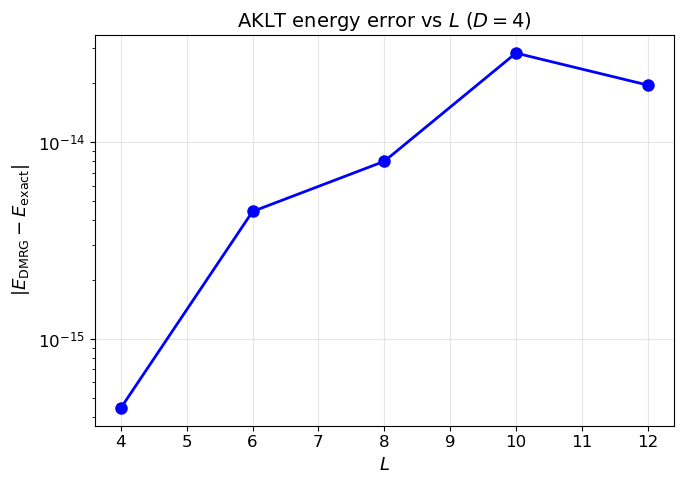

Saved fig6


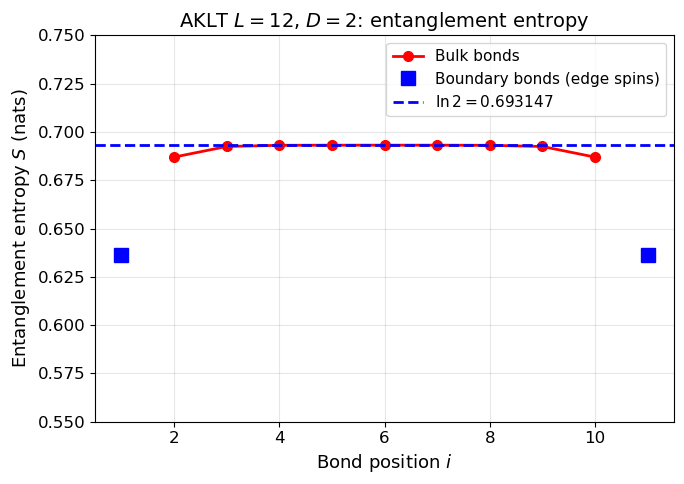

Saved fig7


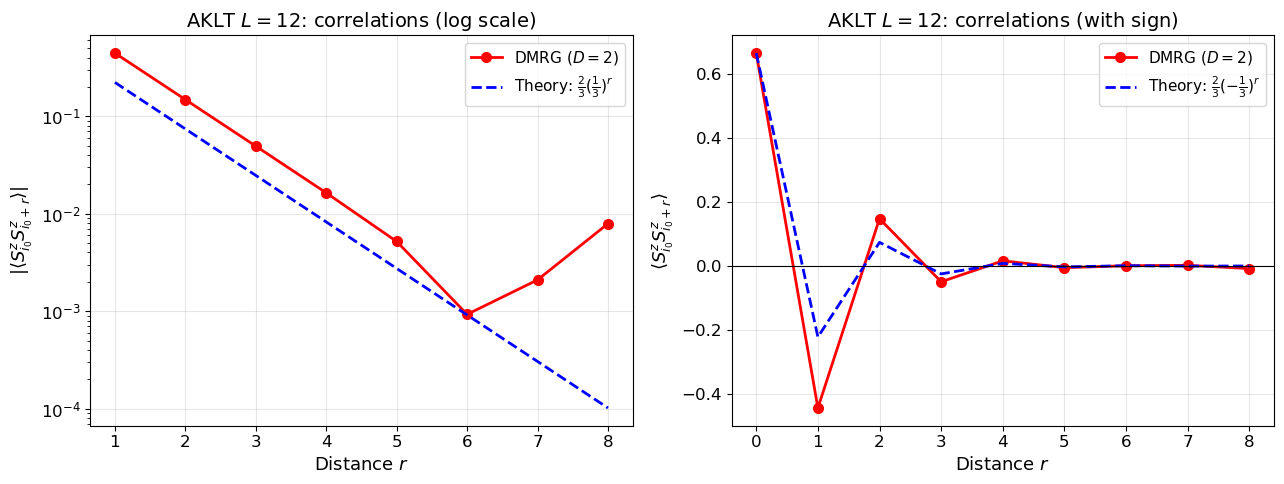

Saved fig8


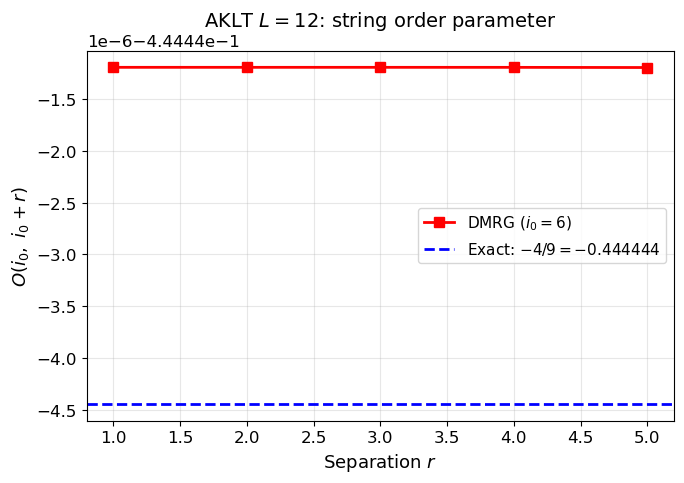

Saved fig9


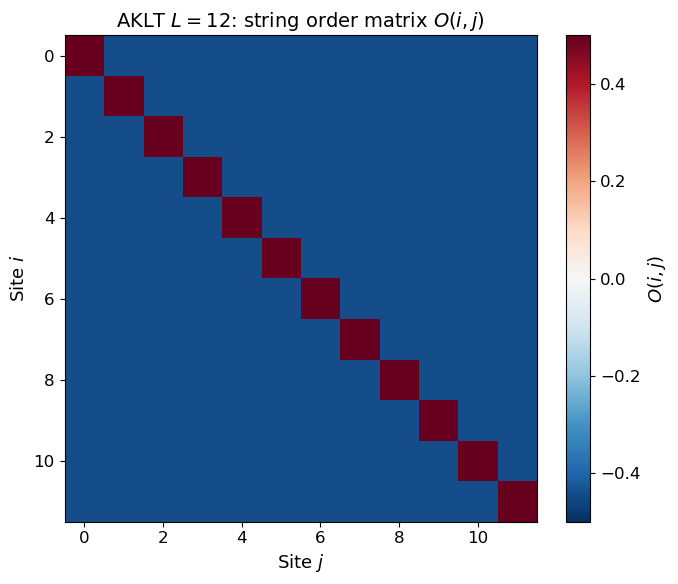

Saved fig10


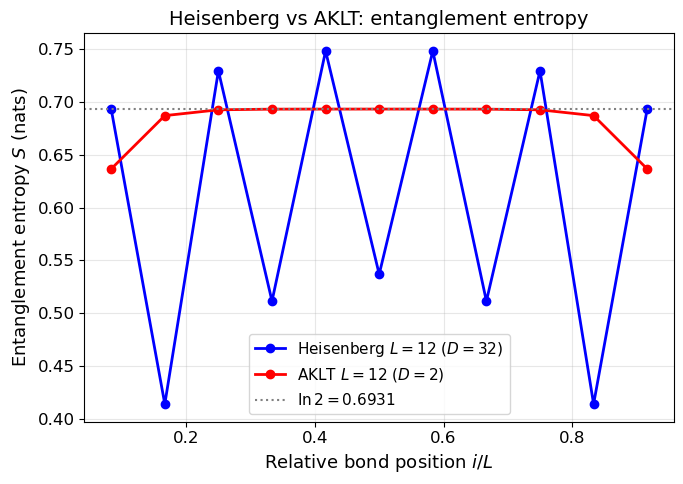

Saved fig11


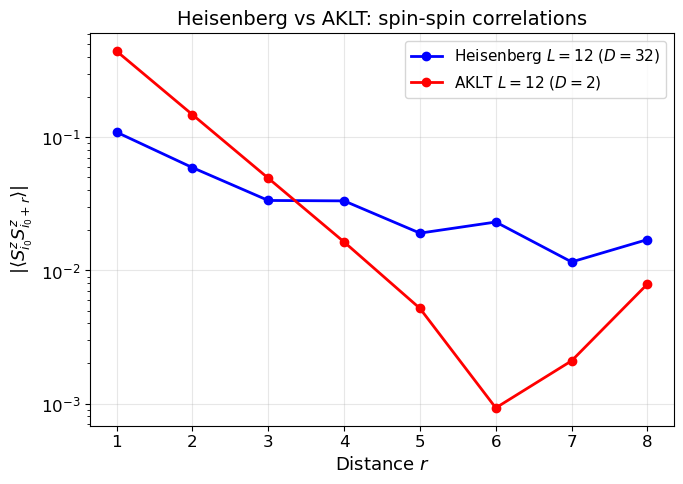

Saved fig12

── Figures saved to figures/ ──
  fig10_aklt_string_matrix.png                           34 KB
  fig11_entropy_comparison.png                           95 KB
  fig12_corr_comparison.png                              63 KB
  fig13_summary_panel.png                               273 KB
  fig1_heisenberg_E_vs_invD.png                          50 KB
  fig2_heisenberg_EperL.png                              61 KB
  fig3_heisenberg_entropy.png                            94 KB
  fig4_heisenberg_corr.png                               66 KB
  fig5_aklt_energy.png                                   47 KB
  fig6_aklt_energy_error.png                             37 KB
  fig7_aklt_entropy.png                                  60 KB
  fig8_aklt_corr.png                                     97 KB
  fig9_aklt_string_order.png                             40 KB

Cell 10 done.


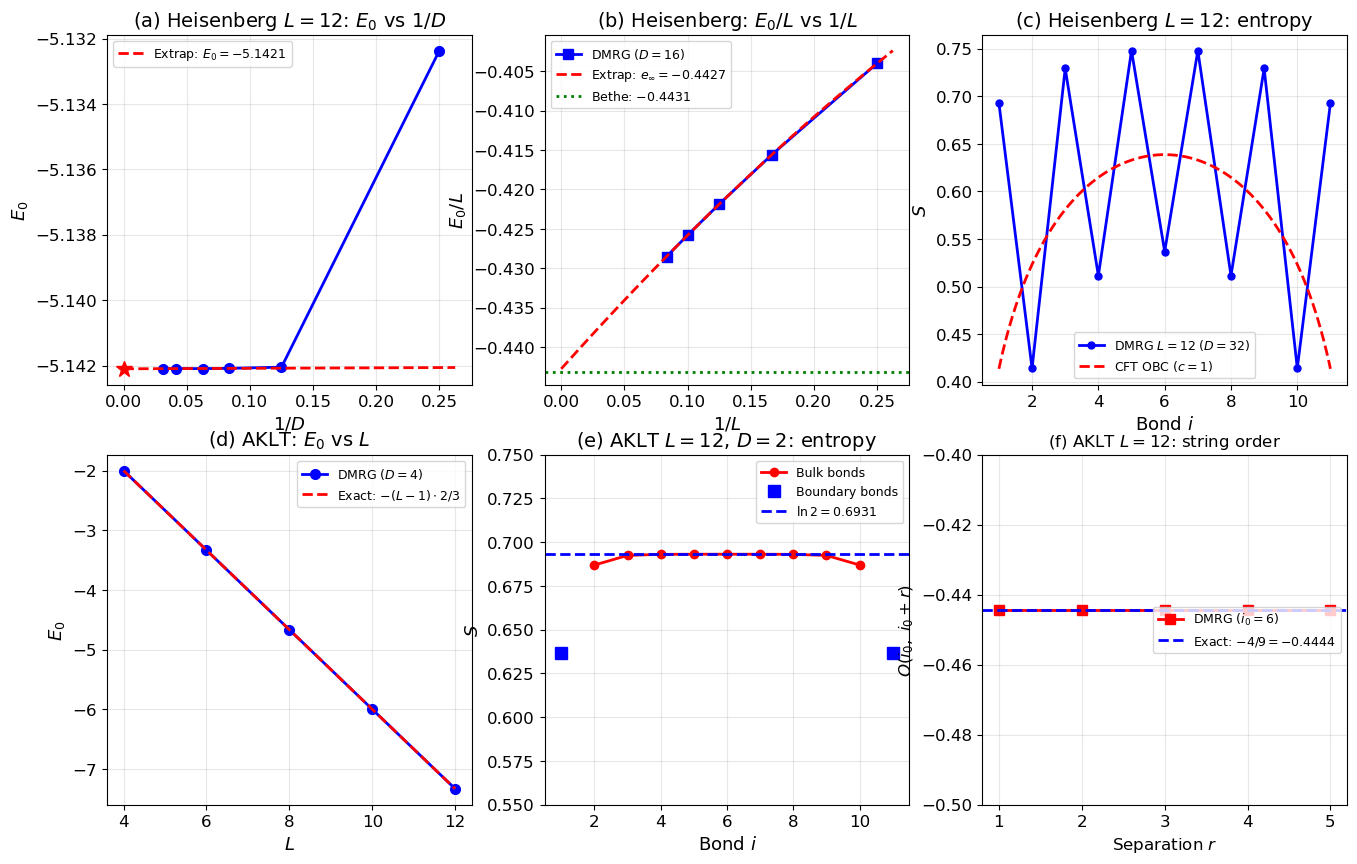

In [ ]:
# ============================================================
# Cell 10 — Figures
# ============================================================
os.makedirs("figures", exist_ok=True)

# ── Derived quantities ────────────────────────────────────────
bonds_h   = np.arange(1, len(S_h)+1)
bonds_a   = np.arange(1, len(S_a)+1)
bulk_mask = (bonds_a > 1) & (bonds_a < len(S_a))
r_h       = np.arange(len(C_h))
r_a       = np.arange(len(C_a))
i_ref     = L_ac//2
r_str     = np.arange(1, L_ac-i_ref)
O_vals    = np.array([O_a[i_ref, i_ref+r] for r in r_str])
C_theory  = np.array([(2./3.)*((-1./3.)**int(r)) for r in r_a])

inv_D     = [1./D for D in D_list]
p_invD    = np.polyfit(inv_D[-4:], E_vs_D[-4:], 1)
x_invD    = np.linspace(0, max(inv_D)*1.05, 200)

inv_L     = [1./L for L in L_list]
EperL     = [E/L  for E,L in zip(E_vs_L, L_list)]
p_extL    = np.polyfit(inv_L, EperL, 2)
x_extL    = np.linspace(0, max(inv_L)*1.05, 200)
e_inf     = np.log(2) - 0.25

# CFT for OBC (c=1): S(i) = (1/6)*ln[sin(pi*i/L)] + const
x_cft     = np.linspace(1, L_heis-1, 300)
S_cft_raw = (1./6.)*np.log(np.sin(np.pi*x_cft/L_heis))
bulk_h    = (bonds_h >= 2) & (bonds_h <= L_heis-2)
cft_at_b  = (1./6.)*np.log(np.sin(np.pi*bonds_h[bulk_h]/L_heis))
cft_shift = np.mean(S_h[bulk_h]) - np.mean(cft_at_b)
S_cft     = S_cft_raw + cft_shift

# ── Fig 1: E vs 1/D ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(inv_D, E_vs_D, 'bo-', ms=8, lw=2, label='DMRG')
ax.plot(x_invD, np.polyval(p_invD,x_invD), 'r--', lw=2,
        label=f'Linear extrap: $E_0(D\\to\\infty)={p_invD[1]:.5f}$')
ax.plot(0, p_invD[1], 'r*', ms=14, zorder=5)
for D,iD,E in zip(D_list, inv_D, E_vs_D):
    ax.annotate(f'$D={D}$', xy=(iD,E),
                xytext=(iD+0.0008, E+0.0003),
                fontsize=8, color='navy')
ax.set_xlabel('$1/D$')
ax.set_ylabel('$E_0$')
ax.set_title(f'Heisenberg $L={L_heis}$: energy vs $1/D$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig1_heisenberg_E_vs_invD.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig1")

# ── Fig 2: E/L vs 1/L ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(inv_L, EperL, 'bs-', ms=8, lw=2, label='DMRG ($D=16$)')
ax.plot(x_extL, np.polyval(p_extL,x_extL), 'r--', lw=2,
        label=f'Quad. extrap: $e_\\infty={p_extL[2]:.5f}$')
ax.axhline(-e_inf, color='g', ls=':', lw=2,
           label=f'Bethe ansatz: $-{e_inf:.5f}$')
# Mark exact ED values
ref_heis = {4:-1.616025403784, 6:-2.493577131515,
            8:-3.374932109083, 10:-4.258035207}
for L_t, E_ref in ref_heis.items():
    if L_t in L_list:
        ax.plot(1./L_t, E_ref/L_t, 'g^', ms=8, zorder=5)
ax.set_xlabel('$1/L$')
ax.set_ylabel('$E_0/L$')
ax.set_title('Heisenberg: bulk energy density vs $1/L$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig2_heisenberg_EperL.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig2")

# ── Fig 3: Heisenberg entanglement entropy ────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(bonds_h, S_h, 'bo-', ms=6, lw=2,
        label=f'DMRG $L={L_heis}$ ($D=32$)')
ax.plot(x_cft, S_cft, 'r--', lw=2,
        label='CFT OBC ($c=1$): '
              '$\\frac{1}{6}\\ln\\sin(\\frac{\\pi i}{L})+{\\rm const}$')
ax.set_xlabel('Bond position $i$')
ax.set_ylabel('Entanglement entropy $S$ (nats)')
ax.set_title(f'Heisenberg $L={L_heis}$ OBC: entanglement entropy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig3_heisenberg_entropy.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig3")

# ── Fig 4: Heisenberg correlations log-log ────────────────────
r_pos   = r_h[1:].astype(float)
C_pos   = np.abs(C_h[1:])
r_even  = r_pos[r_pos%2==0];  C_even = C_pos[r_pos%2==0]
r_odd   = r_pos[r_pos%2==1];  C_odd  = C_pos[r_pos%2==1]
r_guide = np.linspace(1, max(r_pos), 200)
C_guide = C_odd[0]*r_odd[0] / r_guide

fig, ax = plt.subplots(figsize=(7,5))
ax.loglog(r_even, C_even, 'bo-', ms=7, lw=2, label='Even $r$')
ax.loglog(r_odd,  C_odd,  'rs-', ms=7, lw=2, label='Odd $r$')
ax.loglog(r_guide, C_guide, 'g--', lw=2,
          label='$\\sim 1/r$ (critical, $c=1$)')
ax.set_xlabel('Distance $r$')
ax.set_ylabel('$|\\langle S^z_{i_0} S^z_{i_0+r}\\rangle|$')
ax.set_title(f'Heisenberg $L={L_heis}$: correlations (log-log)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("figures/fig4_heisenberg_corr.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig4")

# ── Fig 5: AKLT E vs L ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(L_aklt_list, E_aklt,     'bo-', ms=8, lw=2, label='DMRG ($D=4$)')
ax.plot(L_aklt_list, E_aklt_ref, 'r--', lw=2,
        label='Exact: $-(L-1)\\cdot 2/3$')
ax.set_xlabel('$L$'); ax.set_ylabel('$E_0$')
ax.set_title('AKLT: ground state energy vs $L$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig5_aklt_energy.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig5")

# ── Fig 6: AKLT energy error ──────────────────────────────────
errs_aklt = [abs(E-Er) for E,Er in zip(E_aklt, E_aklt_ref)]
fig, ax = plt.subplots(figsize=(7,5))
ax.semilogy(L_aklt_list, errs_aklt, 'bo-', ms=8, lw=2)
ax.set_xlabel('$L$')
ax.set_ylabel('$|E_{\\rm DMRG} - E_{\\rm exact}|$')
ax.set_title('AKLT energy error vs $L$ ($D=4$)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig6_aklt_energy_error.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig6")

# ── Fig 7: AKLT entanglement entropy ─────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(bonds_a[bulk_mask],  S_a[bulk_mask],
        'ro-', ms=7, lw=2, label='Bulk bonds')
ax.plot(bonds_a[~bulk_mask], S_a[~bulk_mask],
        'bs', ms=10, zorder=5, label='Boundary bonds (edge spins)')
ax.axhline(np.log(2), color='b', ls='--', lw=2,
           label=f'$\\ln 2 = {np.log(2):.6f}$')
ax.set_ylim(0.55, 0.75)
ax.set_xlabel('Bond position $i$')
ax.set_ylabel('Entanglement entropy $S$ (nats)')
ax.set_title(f'AKLT $L={L_ac}$, $D=2$: entanglement entropy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig7_aklt_entropy.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig7")

# ── Fig 8: AKLT correlations ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.semilogy(r_a[1:], np.abs(C_a[1:]), 'ro-', ms=7, lw=2,
            label='DMRG ($D=2$)')
ax.semilogy(r_a[1:], np.abs(C_theory[1:]), 'b--', lw=2,
            label='Theory: $\\frac{2}{3}(\\frac{1}{3})^r$')
ax.set_xlabel('Distance $r$')
ax.set_ylabel('$|\\langle S^z_{i_0} S^z_{i_0+r}\\rangle|$')
ax.set_title(f'AKLT $L={L_ac}$: correlations (log scale)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(r_a, C_a,      'ro-', ms=7, lw=2, label='DMRG ($D=2$)')
ax.plot(r_a, C_theory, 'b--', lw=2,
        label='Theory: $\\frac{2}{3}(-\\frac{1}{3})^r$')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Distance $r$')
ax.set_ylabel('$\\langle S^z_{i_0} S^z_{i_0+r}\\rangle$')
ax.set_title(f'AKLT $L={L_ac}$: correlations (with sign)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig8_aklt_corr.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig8")

# ── Fig 9: AKLT string order ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(r_str, O_vals, 'rs-', ms=7, lw=2,
        label=f'DMRG ($i_0={i_ref}$)')
ax.axhline(-4./9., color='b', ls='--', lw=2,
           label=f'Exact: $-4/9={-4./9.:.6f}$')
ax.set_xlabel('Separation $r$')
ax.set_ylabel('$O(i_0,\\ i_0+r)$')
ax.set_title(f'AKLT $L={L_ac}$: string order parameter')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig9_aklt_string_order.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig9")

# ── Fig 10: AKLT string order matrix ─────────────────────────
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(O_a, origin='upper', cmap='RdBu_r',
               vmin=-0.5, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax, label='$O(i,j)$')
ax.set_xlabel('Site $j$'); ax.set_ylabel('Site $i$')
ax.set_title(f'AKLT $L={L_ac}$: string order matrix $O(i,j)$')
plt.tight_layout()
plt.savefig("figures/fig10_aklt_string_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig10")

# ── Fig 11: Entropy comparison ────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(bonds_h/L_heis, S_h, 'bo-', ms=6, lw=2,
        label=f'Heisenberg $L={L_heis}$ ($D=32$)')
ax.plot(bonds_a/L_ac,   S_a, 'ro-', ms=6, lw=2,
        label=f'AKLT $L={L_ac}$ ($D=2$)')
ax.axhline(np.log(2), color='gray', ls=':', lw=1.5,
           label=f'$\\ln 2={np.log(2):.4f}$')
ax.set_xlabel('Relative bond position $i/L$')
ax.set_ylabel('Entanglement entropy $S$ (nats)')
ax.set_title('Heisenberg vs AKLT: entanglement entropy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig11_entropy_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig11")

# ── Fig 12: Correlations comparison ──────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.semilogy(r_h[1:], np.abs(C_h[1:]), 'bo-', ms=6, lw=2,
            label=f'Heisenberg $L={L_heis}$ ($D=32$)')
ax.semilogy(r_a[1:], np.abs(C_a[1:]), 'ro-', ms=6, lw=2,
            label=f'AKLT $L={L_ac}$ ($D=2$)')
ax.set_xlabel('Distance $r$')
ax.set_ylabel('$|\\langle S^z_{i_0} S^z_{i_0+r}\\rangle|$')
ax.set_title('Heisenberg vs AKLT: spin-spin correlations')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig12_corr_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig12")

# ── Fig 13: Summary panel (2x3) ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16,10))

# (a) E vs 1/D
ax = axes[0,0]
ax.plot(inv_D, E_vs_D, 'bo-', ms=7, lw=2)
ax.plot(x_invD, np.polyval(p_invD,x_invD), 'r--', lw=2,
        label=f'Extrap: $E_0={p_invD[1]:.4f}$')
ax.plot(0, p_invD[1], 'r*', ms=12, zorder=5)
ax.set_xlabel('$1/D$'); ax.set_ylabel('$E_0$')
ax.set_title(f'(a) Heisenberg $L={L_heis}$: $E_0$ vs $1/D$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (b) E/L vs 1/L
ax = axes[0,1]
ax.plot(inv_L, EperL, 'bs-', ms=7, lw=2, label='DMRG ($D=16$)')
ax.plot(x_extL, np.polyval(p_extL,x_extL), 'r--', lw=2,
        label=f'Extrap: $e_\\infty={p_extL[2]:.4f}$')
ax.axhline(-e_inf, color='g', ls=':', lw=2,
           label=f'Bethe: $-{e_inf:.4f}$')
ax.set_xlabel('$1/L$'); ax.set_ylabel('$E_0/L$')
ax.set_title('(b) Heisenberg: $E_0/L$ vs $1/L$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (c) Heisenberg entropy
ax = axes[0,2]
ax.plot(bonds_h, S_h, 'bo-', ms=5, lw=2,
        label=f'DMRG $L={L_heis}$ ($D=32$)')
ax.plot(x_cft, S_cft, 'r--', lw=2, label='CFT OBC ($c=1$)')
ax.set_xlabel('Bond $i$'); ax.set_ylabel('$S$')
ax.set_title(f'(c) Heisenberg $L={L_heis}$: entropy')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (d) AKLT E vs L
ax = axes[1,0]
ax.plot(L_aklt_list, E_aklt,     'bo-', ms=7, lw=2,
        label='DMRG ($D=4$)')
ax.plot(L_aklt_list, E_aklt_ref, 'r--', lw=2,
        label='Exact: $-(L-1)\\cdot 2/3$')
ax.set_xlabel('$L$'); ax.set_ylabel('$E_0$')
ax.set_title('(d) AKLT: $E_0$ vs $L$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (e) AKLT entropy
ax = axes[1,1]
ax.plot(bonds_a[bulk_mask],  S_a[bulk_mask],
        'ro-', ms=6, lw=2, label='Bulk bonds')
ax.plot(bonds_a[~bulk_mask], S_a[~bulk_mask],
        'bs', ms=9, zorder=5, label='Boundary bonds')
ax.axhline(np.log(2), color='b', ls='--', lw=2,
           label=f'$\\ln 2={np.log(2):.4f}$')
ax.set_ylim(0.55, 0.75)
ax.set_xlabel('Bond $i$'); ax.set_ylabel('$S$')
ax.set_title(f'(e) AKLT $L={L_ac}$, $D=2$: entropy')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (f) AKLT string order
ax = axes[1,2]
ax.plot(r_str, O_vals, 'rs-', ms=7, lw=2,
        label=f'DMRG ($i_0={i_ref}$)')
ax.axhline(-4./9., color='b', ls='--', lw=2,
           label=f'Exact: $-4/9={-4./9.:.4f}$')

# --- THE FIX: Force a sensible physical scale ---
ax.set_ylim(-0.50, -0.40) 

ax.set_xlabel('Separation $r$', fontsize=12)
ax.set_ylabel('$O(i_0,\\ i_0+r)$', fontsize=12)
ax.set_title(f'(f) AKLT $L={L_ac}$: string order', fontsize=12)
ax.legend(fontsize=9, loc='center right')
ax.grid(True, alpha=0.3)

# ── Final file listing ────────────────────────────────────────
print("\n── Figures saved to figures/ ──")
for f in sorted(os.listdir("figures")):
    fpath = os.path.join("figures", f)
    size  = os.path.getsize(fpath)
    print(f"  {f:50s}  {size//1024:5d} KB")

print("\nCell 10 done.")

In [11]:
# ============================================================
# Cell 11 — Final verification summary
# ============================================================
print("=" * 60)
print("FINAL VERIFICATION SUMMARY")
print("=" * 60)

print("\n1. Heisenberg MPO exact-diag reference values:")
ref_heis = {4:-1.616025403784, 6:-2.493577131515,
            8:-3.374932109083, 10:-4.258035207}
for L_t, E_ref in ref_heis.items():
    E0,_,_ = mpo_exact_gs(build_heisenberg_mpo(L_t), d=2)
    print(f"   L={L_t:2d}: E={E0:.12f}  err={abs(E0-E_ref):.2e}")

print("\n2. Heisenberg DMRG vs exact diag:")
for L_t, E_ref in ref_heis.items():
    Es,_,_ = dmrg_single_site(build_heisenberg_mpo(L_t), d=2,
                               D_max=16, n_sweeps=30, conv_tol=1e-10,
                               seed=0, verbose=False)
    print(f"   L={L_t:2d}: E={Es[-1]:.12f}  err={abs(Es[-1]-E_ref):.2e}")

print

FINAL VERIFICATION SUMMARY

1. Heisenberg MPO exact-diag reference values:
   L= 4: E=-1.616025403784  err=4.39e-13
   L= 6: E=-2.493577133888  err=2.37e-09
   L= 8: E=-3.374932598688  err=4.90e-07
   L=10: E=-4.258035207283  err=2.83e-10

2. Heisenberg DMRG vs exact diag:
   L= 4: E=-1.616025403784  err=4.39e-13
   L= 6: E=-2.493577133888  err=2.37e-09
   L= 8: E=-3.374932598688  err=4.90e-07
   L=10: E=-4.258035204636  err=2.36e-09


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

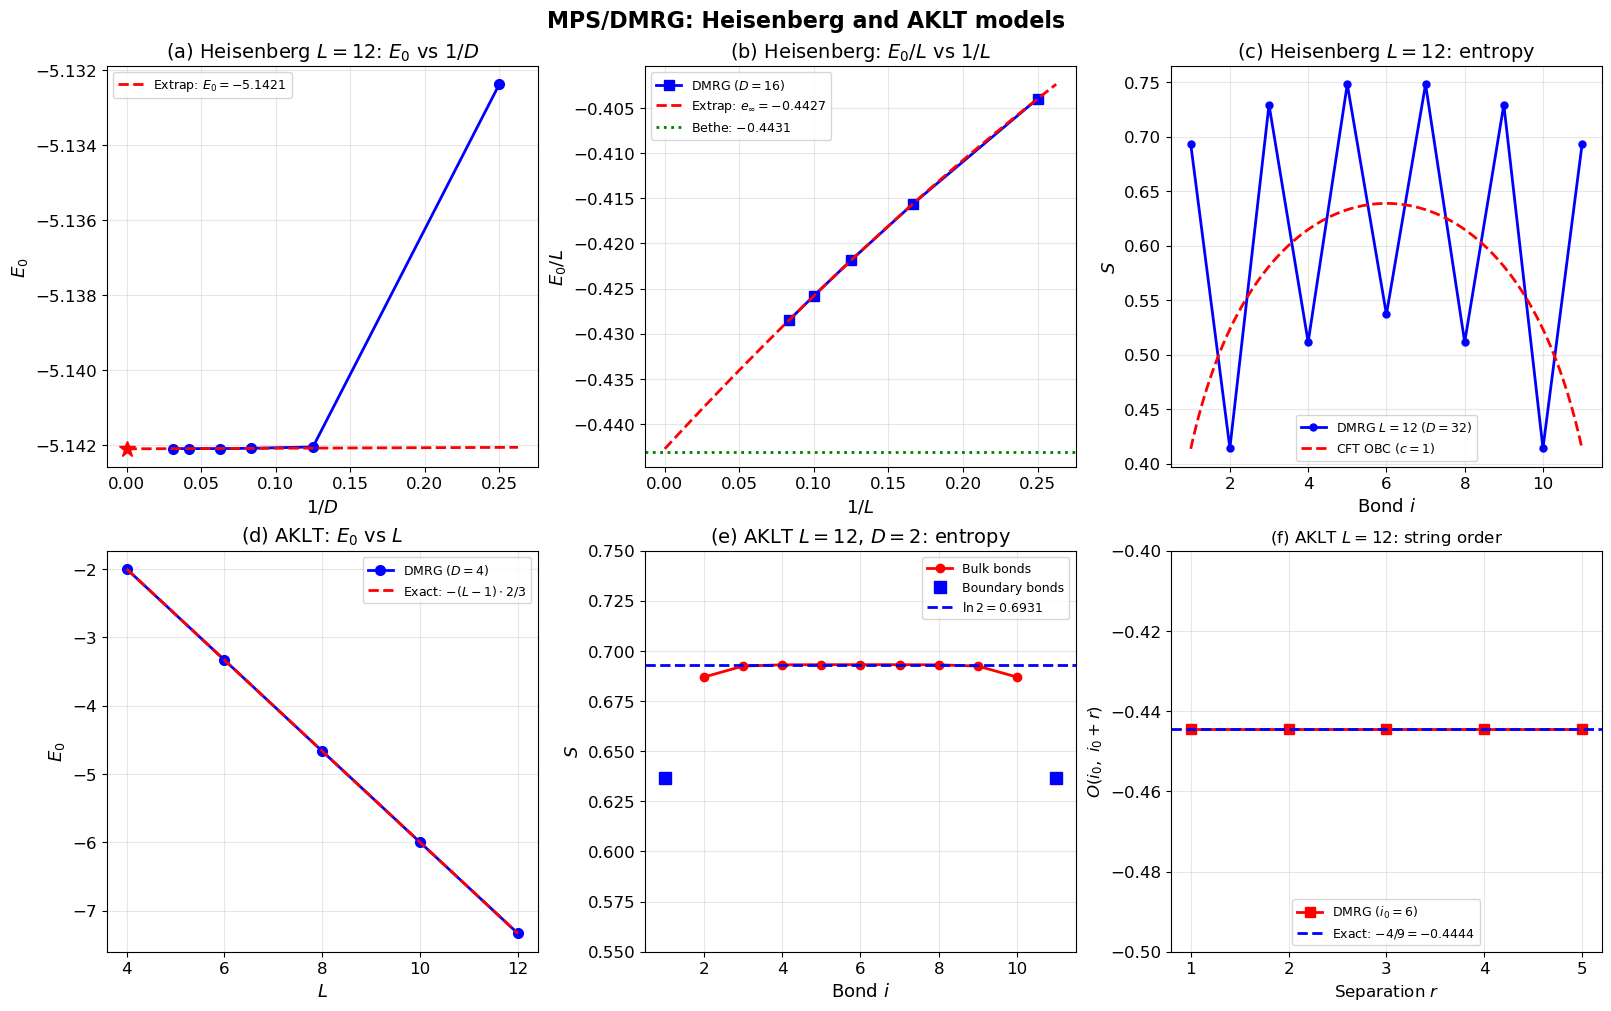

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ── Fig 13: Summary panel (2x3) ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16,10), constrained_layout=True)

# (a) E vs 1/D
ax = axes[0,0]
ax.plot(inv_D, E_vs_D, 'bo-', ms=7, lw=2)
ax.plot(x_invD, np.polyval(p_invD,x_invD), 'r--', lw=2,
        label=f'Extrap: $E_0={p_invD[1]:.4f}$')
ax.plot(0, p_invD[1], 'r*', ms=12, zorder=5)
ax.set_xlabel('$1/D$'); ax.set_ylabel('$E_0$')
ax.set_title(f'(a) Heisenberg $L={L_heis}$: $E_0$ vs $1/D$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (b) E/L vs 1/L
ax = axes[0,1]
ax.plot(inv_L, EperL, 'bs-', ms=7, lw=2, label='DMRG ($D=16$)')
ax.plot(x_extL, np.polyval(p_extL,x_extL), 'r--', lw=2,
        label=f'Extrap: $e_\\infty={p_extL[2]:.4f}$')
ax.axhline(-e_inf, color='g', ls=':', lw=2,
           label=f'Bethe: $-{e_inf:.4f}$')
ax.set_xlabel('$1/L$'); ax.set_ylabel('$E_0/L$')
ax.set_title('(b) Heisenberg: $E_0/L$ vs $1/L$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (c) Heisenberg entropy
ax = axes[0,2]
ax.plot(bonds_h, S_h, 'bo-', ms=5, lw=2,
        label=f'DMRG $L={L_heis}$ ($D=32$)')
ax.plot(x_cft, S_cft, 'r--', lw=2, label='CFT OBC ($c=1$)')
ax.set_xlabel('Bond $i$'); ax.set_ylabel('$S$')
ax.set_title(f'(c) Heisenberg $L={L_heis}$: entropy')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (d) AKLT E vs L
ax = axes[1,0]
ax.plot(L_aklt_list, E_aklt,     'bo-', ms=7, lw=2,
        label='DMRG ($D=4$)')
ax.plot(L_aklt_list, E_aklt_ref, 'r--', lw=2,
        label='Exact: $-(L-1)\\cdot 2/3$')
ax.set_xlabel('$L$'); ax.set_ylabel('$E_0$')
ax.set_title('(d) AKLT: $E_0$ vs $L$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (e) AKLT entropy
ax = axes[1,1]
ax.plot(bonds_a[bulk_mask],  S_a[bulk_mask],
        'ro-', ms=6, lw=2, label='Bulk bonds')
ax.plot(bonds_a[~bulk_mask], S_a[~bulk_mask],
        'bs', ms=9, zorder=5, label='Boundary bonds')
ax.axhline(np.log(2), color='b', ls='--', lw=2,
           label=f'$\\ln 2={np.log(2):.4f}$')
ax.set_ylim(0.55, 0.75)
ax.set_xlabel('Bond $i$'); ax.set_ylabel('$S$')
ax.set_title(f'(e) AKLT $L={L_ac}$, $D=2$: entropy')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (f) AKLT string order
ax = axes[1,2]
ax.plot(r_str, O_vals, 'rs-', ms=7, lw=2,
        label=f'DMRG ($i_0={i_ref}$)')
ax.axhline(-4./9., color='b', ls='--', lw=2,
           label=f'Exact: $-4/9={-4./9.:.4f}$')

ax.set_ylim(-0.50, -0.40) 

ax.set_xlabel('Separation $r$', fontsize=12)
ax.set_ylabel('$O(i_0,\\ i_0+r)$', fontsize=12)
ax.set_title(f'(f) AKLT $L={L_ac}$: string order', fontsize=12)

# FIX 3: Moved legend to lower center!
ax.legend(fontsize=9, loc='lower center')
ax.grid(True, alpha=0.3)

# ── Save and Show the Figure ──────────────────────────────────
fig.suptitle('MPS/DMRG: Heisenberg and AKLT models', fontsize=16, fontweight='bold')

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/fig_physics.png", dpi=150, bbox_inches='tight')
plt.show()